# Production Technology

The dataset contains `N = 441` firms observed over `T = 12` years, 1968-1979. There variables are: 
* `lcap`: Log of capital stock, $k_{it}$ 
* `lemp`: log of employment, $\ell_{it}$ 
* `ldsa`: log of deflated sales, $y_{it}$
* `year`: the calendar year of the observation, `year` $ = 1968, ..., 1979$, 
* `firmid`: anonymized indicator variable for the firm, $i = 1, ..., N$, with $N=441$. 

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2

import w3_LinearModels as lm


In [2]:
dat = pd.read_csv('firms.csv')

In [3]:
dat.sample(5)

,firmid,year,lcap,lemp,ldsa
2432,203,1976,1.702095,1.348899,1.396998
4991,416,1979,-1.593710,-2.029850,-1.416720
5146,429,1978,-0.911492,-0.604277,-0.923959
4141,346,1969,-0.889350,-0.383296,0.205996
1215,102,1971,-0.218694,0.004605,-0.356035


In [4]:
# Is data balanced?
N = dat.firmid.unique().size
T = dat.year.unique().size
assert dat.shape[0] == (N*T), f'Error: data is not a balanced panel'
print(f'Data has N={N} and T={T}')

Data has N=441 and T=12


# Descriptives

### Labor

Text(0, 0.5, 'log sales')

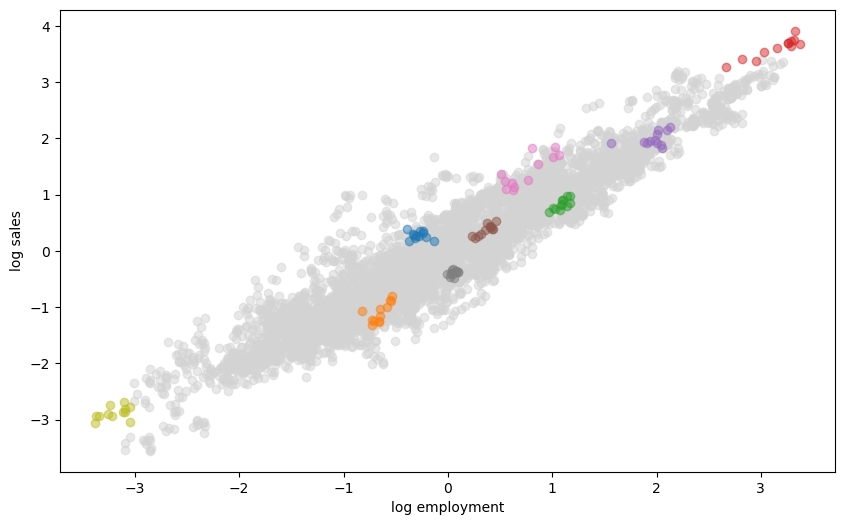

In [5]:
plt.figure(figsize=(10,6))
ax = plt.subplot(1,1,1)

#highlight_firms = [i for i in range(1, 100, by=10)]
#highlight_firms = np.linspace(1, 100, 10, dtype=int)
highlight_firms = [1, 5, 7, 8, 16, 24, 39, 101, 204]

mask_bg = dat['firmid'].isin(highlight_firms) == False
mask_fg = dat['firmid'].isin(highlight_firms)

ax.scatter(dat.loc[mask_bg, 'lemp'], dat.loc[mask_bg, 'ldsa'], color='lightgrey', alpha=0.5, zorder=1, label='other firms')

for firm, group in dat.loc[mask_fg].groupby('firmid'):
    ax.scatter(group['lemp'], group['ldsa'], label=f'firm {firm}', alpha=0.5, zorder=2)

ax.set_xlabel('log employment')
ax.set_ylabel('log sales')


Text(0, 0.5, 'log sales')

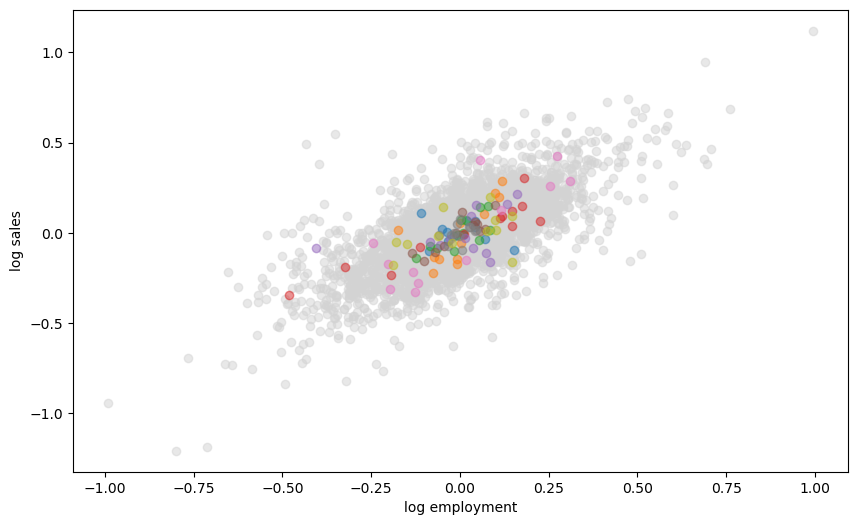

In [6]:
# Demean data
dat_demean = dat - dat.groupby("firmid").transform('mean')
dat_demean['firmid'] = dat['firmid']


highlight_firms = [1, 5, 7, 8, 16, 24, 39, 101, 204]

mask_bg = dat['firmid'].isin(highlight_firms) == False
mask_fg = dat['firmid'].isin(highlight_firms)

plt.figure(figsize=(10,6))
ax = plt.subplot(1,1,1)

ax.scatter(dat_demean.loc[mask_bg, 'lemp'], dat_demean.loc[mask_bg, 'ldsa'], color='lightgrey', alpha=0.5, zorder=1, label='other firms')

for firm, group in dat_demean.loc[mask_fg].groupby('firmid'):
    ax.scatter(group['lemp'], group['ldsa'], label=f'firm {firm}', alpha=0.5, zorder=2)

ax.set_xlabel('log employment')
ax.set_ylabel('log sales')

### Capital

Text(0, 0.5, 'log sales')

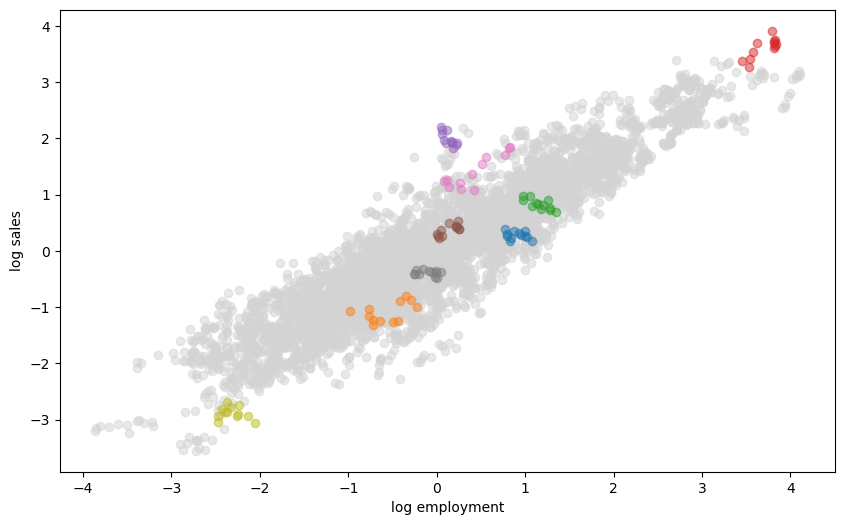

In [7]:
plt.figure(figsize=(10,6))
ax = plt.subplot(1,1,1)

#highlight_firms = [i for i in range(1, 100, by=10)]
#highlight_firms = np.linspace(1, 100, 10, dtype=int)
highlight_firms = [1, 5, 7, 8, 16, 24, 39, 101, 204]

mask_bg = dat['firmid'].isin(highlight_firms) == False
mask_fg = dat['firmid'].isin(highlight_firms)

ax.scatter(dat.loc[mask_bg, 'lcap'], dat.loc[mask_bg, 'ldsa'], color='lightgrey', alpha=0.5, zorder=1, label='other firms')

for firm, group in dat.loc[mask_fg].groupby('firmid'):
    ax.scatter(group['lcap'], group['ldsa'], label=f'firm {firm}', alpha=0.5, zorder=2)

ax.set_xlabel('log employment')
ax.set_ylabel('log sales')

Text(0, 0.5, 'log sales')

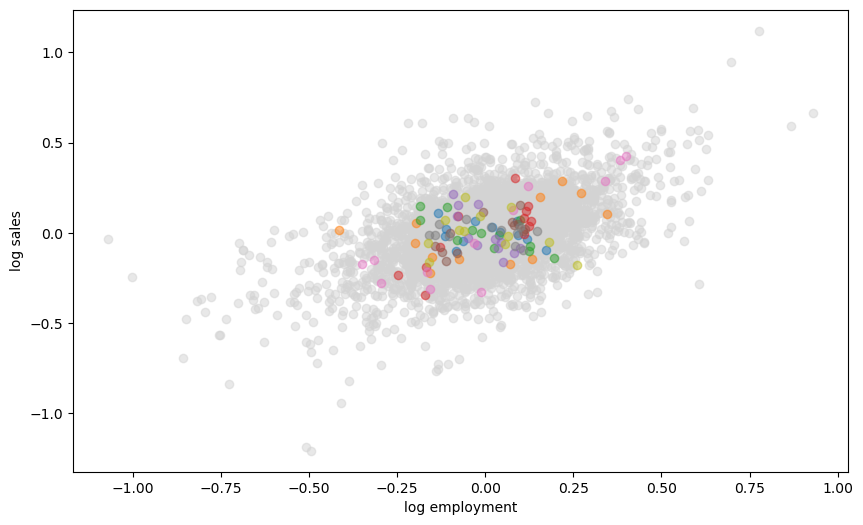

In [8]:

highlight_firms = [1, 5, 7, 8, 16, 24, 39, 101, 204]

mask_bg = dat['firmid'].isin(highlight_firms) == False
mask_fg = dat['firmid'].isin(highlight_firms)

plt.figure(figsize=(10,6))
ax = plt.subplot(1,1,1)

ax.scatter(dat_demean.loc[mask_bg, 'lcap'], dat_demean.loc[mask_bg, 'ldsa'], color='lightgrey', alpha=0.5, zorder=1, label='other firms')

for firm, group in dat_demean.loc[mask_fg].groupby('firmid'):
    ax.scatter(group['lcap'], group['ldsa'], label=f'firm {firm}', alpha=0.5, zorder=2)

ax.set_xlabel('log employment')
ax.set_ylabel('log sales')

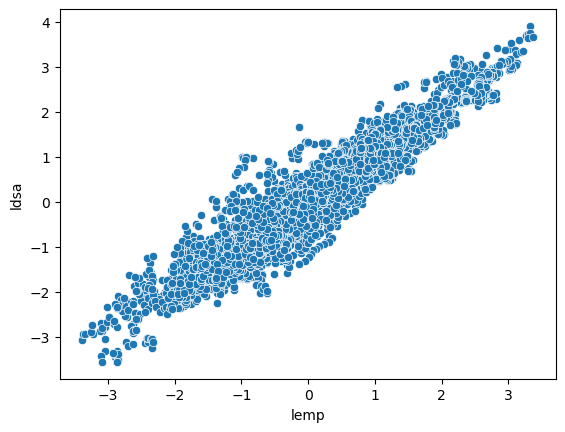

In [9]:
sns.scatterplot(x='lemp', y='ldsa', data=dat); 

# Converting data to numpy format 

In [10]:
dat.ldsa.values.shape

(5292,)

Extract data from `pandas` to `numpy` arrays. 

In [11]:
y = dat.ldsa.values.reshape((N*T,1))

ones = np.ones((N*T,1))
l = dat.lemp.values.reshape((N*T,1))
k = dat.lcap.values.reshape((N*T,1))
X = np.hstack([ones, l, k])


# Create labels
label_x = ['constant', 'log employment', 'log capital']
label_y = 'log sales'


# POOLED OLS

In [12]:
pols_result = lm.estimate(y=y, x=X, robust_se=True)
lm.print_table((label_y, label_x), pols_result)

Results
Dependent variable: log sales

                Beta              Se            t-values
--------------  ----------------  ------------  ----------------
constant        [1.53587613e-08]  [0.00497068]  [3.08987297e-06]
log employment  [0.67477449]      [0.01153363]  [58.50496543]
log capital     [0.31004076]      [0.01017528]  [30.46998657]
R² = 0.914
σ² = 0.131


### TESTING CONSTANT RETURN TO SCALE

In [13]:
# Creating restriction vector to point out relevant betas
R = np.array([[0, 1, 1]])
r = np.array([1])

# WALD test statistic
w = (R@pols_result['b_hat'] - r).T @ np.linalg.inv(R@pols_result['cov']@R.T)@(R@pols_result['b_hat'] - r)

# P-value and critical value
p_value = 1 - chi2.cdf(w, df=1)

critical_value = chi2.ppf(0.95, df=1)

#Output
print(f'Wald test statistic: {w.item():.4f}')
print(f'p-value: {p_value.item():.4f}')
print(f'Critical value (5%): {critical_value:.4f}')

Wald test statistic: 15.3365
p-value: 0.0001
Critical value (5%): 3.8415


# FE

In [14]:
def remove_zero_columns(x, label_x):
    """
    The function removes columns from a matrix that are all zeros and returns the updated matrix and
    corresponding labels.
    
    Args:
      x: The parameter `x` is a numpy array representing a matrix with columns that may contain zeros.
      label_x: The parameter `label_x` is a list that contains the labels for each column in the input
    array `x`.
    
    Returns:
      x_nonzero: numpy array of x with columns that are all zeros removed.
      label_nonzero: list of labels for each column in x_nonzero.
    """
    
    # Find the columns that are not all zeros
    nonzero_cols = ~np.all(x == 0, axis=0)
    
    # Remove the columns that are all zeros
    x_nonzero = x[:, nonzero_cols]
    
    # Get the labels for the columns that are not all zeros
    label_nonzero = [label_x[i] for i in range(len(label_x)) if nonzero_cols[i]]
    return x_nonzero, label_nonzero

In [15]:
# Transform the data
Q_T = np.eye(N=T, M=T) - 1/T*np.ones((T,T)) # Fill in
y_dot = lm.perm(Q_T, A=y) # Fill in
x_dot = lm.perm(Q_T, A=X) # Fill in

# Due to rounding errors, some values that should be zero are not exactly zero. We set them to zero
x_dot[:, 0] = 0

# Remove the columns that are only zeroes
x_dot, label_x_dot = remove_zero_columns(x_dot, label_x) # Fill in

# Estimate 
fe_result = lm.estimate(y_dot, x_dot, transform='fe', T=T, robust_se=True) # Fill in
lm.print_table((label_y, label_x_dot), fe_result, title="Fixed Effects", floatfmt='.4f')

Fixed Effects
Dependent variable: log sales

                Beta          Se            t-values
--------------  ------------  ------------  -------------
log employment  [0.69422625]  [0.04165182]  [16.66737035]
log capital     [0.15461952]  [0.02994777]  [5.16297184]
R² = 0.477
σ² = 0.018


### TEST FOR CONSTANT RETURN TO SCALE

In [16]:
# Creating restriction vector to point out relevant betas
R = np.array([[1, 1]])
r = np.array([1])

# WALD test statistic
w = (R@fe_result['b_hat'] - r).T @ np.linalg.inv(R@fe_result['cov']@R.T)@(R@fe_result['b_hat'] - r)

# P-value and critical value
p_value = 1 - chi2.cdf(w, df=1)

critical_value = chi2.ppf(0.95, df=1)

#Output
print(f'Wald test statistic: {w.item():.4f}')
print(f'p-value: {p_value.item():.4f}')
print(f'Critical value (5%): {critical_value:.4f}')

Wald test statistic: 19.4029
p-value: 0.0000
Critical value (5%): 3.8415


In [17]:
fe_table = pd.DataFrame(
    {
        "Coefficient": fe_result["b_hat"].ravel(),
        "Std. Error": fe_result["se"].ravel(),
        "t-value": fe_result["t_values"].ravel(),
    },
    index=label_x_dot,
)
fe_table.index.name = "Variable"

fe_latex = fe_table.to_latex(float_format="%.4f", escape=True)
with open("fe_result.tex", "w") as file:
    file.write(fe_latex)

print(fe_latex)


\begin{tabular}{lrrr}
\toprule
 & Coefficient & Std. Error & t-value \\
Variable &  &  &  \\
\midrule
log employment & 0.6942 & 0.0417 & 16.6674 \\
log capital & 0.1546 & 0.0299 & 5.1630 \\
\bottomrule
\end{tabular}



# FD

In [18]:
# Transform the data
D_T = -1*np.eye(T-1, T)+np.eye(T-1, T, k=1) 
y_diff = lm.perm(D_T, y) 
x_diff = lm.perm(D_T, X) 

# Remove the columns that are only zeroes
x_diff, label_x_diff = remove_zero_columns(x_diff, label_x) # Fill in

# Estimate 
fd_result = lm.estimate(y_diff, x_diff, transform='fd', robust_se=True) # Fill in
lm.print_table((label_y, label_x_diff), fd_result, title="First Difference", floatfmt='.4f')

First Difference
Dependent variable: log sales

                Beta          Se            t-values
--------------  ------------  ------------  -------------
log employment  [0.54866574]  [0.02751857]  [19.93801594]
log capital     [0.06296038]  [0.0234754]   [2.68197267]
R² = 0.165
σ² = 0.014


### TEST FOR CONSTANT RETURN TO SCALE

In [19]:
# Creating restriction vector to point out relevant betas
R = np.array([[1, 1]])
r = np.array([1])

# WALD test statistic
w = (R@fd_result['b_hat'] - r).T @ np.linalg.inv(R@fd_result['cov']@R.T)@(R@fd_result['b_hat'] - r)

# P-value and critical value
p_value = 1 - chi2.cdf(w, df=1)

critical_value = chi2.ppf(0.95, df=1)

#Output
print(f'Wald test statistic: {w.item():.4f}')
print(f'p-value: {p_value.item():.4f}')
print(f'Critical value (5%): {critical_value:.4f}')

Wald test statistic: 134.9740
p-value: 0.0000
Critical value (5%): 3.8415


# TEST FOR STRICT EXOGENERITY

## SIMPLE TESTS

### FE

In [20]:
# Create leading matrix
F_T = np.column_stack((np.zeros(T-1), np.eye(T-1))) 

# Lead labor and capital
labor_lead = lm.perm(F_T, X[:, 1].reshape(-1, 1))
capital_lead = lm.perm(F_T, X[:, 2].reshape(-1, 1))

In [21]:
# Remove the last observed year for every individual
I_T = np.column_stack((np.eye(T-1), np.zeros(T-1))) 

x_exo = lm.perm(I_T, X)
y_exo = lm.perm(I_T, y)

In [22]:
# Add capital_lead and labor_lead to x_exo
x_exo = np.hstack((x_exo, labor_lead, capital_lead))

# Within transform the data
Q_T = np.eye(N=T-1, M=T-1) - 1/(T-1)*np.ones((T-1,T-1))
yw_exo = lm.perm(Q_T=Q_T, A=y_exo)
xw_exo = lm.perm(Q_T=Q_T, A=x_exo)

# Drop constant column as it is not identified in the within transformation
xw_exo[:, 0] = 0

# Remove non-zero columns
xw_exo, label_xw_exo = remove_zero_columns(xw_exo, label_x + ['labor_lead', 'capital_lead'])

In [23]:
# Estimate model
exo_test = lm.estimate(yw_exo, xw_exo, transform='fe', T=(T-1), robust_se=True)
# Print results
lm.print_table((label_y, label_xw_exo), exo_test, title='Exogeneity test', floatfmt='.4f')


Exogeneity test
Dependent variable: log sales

                Beta          Se            t-values
--------------  ------------  ------------  -------------
log employment  [0.54082746]  [0.04307245]  [12.55622725]
log capital     [0.02799744]  [0.03754258]  [0.74575146]
labor_lead      [0.14194843]  [0.02829232]  [5.01720705]
capital_lead    [0.16672914]  [0.04566195]  [3.65137998]
R² = 0.478
σ² = 0.016


In [24]:
# WALD TEST
# Construct R matrix that points out the coefficients of the two lead variables
R = np.array([[0, 0, 1, 0], [0, 0, 0, 1]])
r = np.array([[0], [0]])

# Construct the Wald test statistic
W = (R @ exo_test['b_hat'] - r).T @ np.linalg.inv(R @ exo_test['cov'] @ R.T) @ (R @ exo_test['b_hat'] - r)

# H0: The coefficients of the two lead variables are equal to zero (i.e. strict exogeneity "holds")
# This test is chi_square distributed with 2 degrees of freedom
p_value = 1 - chi2.cdf(W, df=2)

# Critical value for 5% significance level
critical_value = chi2.ppf(0.95, df=2)


# CONCLUSION:
print(f"Wald test statistic: {W[0][0]:.4f}")
print(f"Critical value (5% significance level): {critical_value:.4f}")
print(f"P-value: {p_value[0][0]:.4f}")

Wald test statistic: 44.1107
Critical value (5% significance level): 5.9915
P-value: 0.0000


### FD

In [25]:
## Test for strict exogeneity using FD

# Drop first time-period for all firms
I_T = np.column_stack((np.zeros(T-1), np.eye(T-1))) 
w = lm.perm(I_T, X)

# Keep only capital and labor
w = w[:, 1:3]  # Keep only the columns for labor and capital


# Stack x_diff and w
xw_exo_fd = np.hstack((x_diff, w))

# Remove non-zero columns
labels_xw_exo_fd = label_x_diff + ['log employment level', 'log capital level']

# Estimate model
exo_test_fd = lm.estimate(y_diff, xw_exo_fd, transform='fd', robust_se=True)

# Print results
lm.print_table((label_y, labels_xw_exo_fd), exo_test_fd, title='Exogeneity test', floatfmt='.4f')


Exogeneity test
Dependent variable: log sales

                      Beta           Se            t-values
--------------------  -------------  ------------  -------------
log employment        [0.54384673]   [0.0280117]   [19.41498583]
log capital           [0.06113151]   [0.02358845]  [2.59158655]
log employment level  [0.00445267]   [0.00377739]  [1.17877026]
log capital level     [-0.00463472]  [0.00327355]  [-1.41580841]
R² = 0.165
σ² = 0.014


In [26]:
# WALD TEST
# Construct R matrix that points out the coefficients of the two level variables
R = np.array([[0, 0, 1, 0], [0, 0, 0, 1]])
r = np.array([[0], [0]])

# Construct the Wald test statistic
W = (R @ exo_test_fd['b_hat'] - r).T @ np.linalg.inv(R @ exo_test_fd['cov'] @ R.T) @ (R @ exo_test_fd['b_hat'] - r)

# H0: The coefficients of the two level variables are equal to zero (i.e. strict exogeneity "holds")
# This test is chi_square distributed with 2 degrees of freedom
p_value = 1 - chi2.cdf(W, df=2)

# Critical value for 5% significance level
critical_value = chi2.ppf(0.95, df=2)


# CONCLUSION:
print(f"Wald test statistic: {W[0][0]:.4f}")
print(f"Critical value (5% significance level): {critical_value:.4f}")
print(f"P-value: {p_value[0][0]:.4f}")

Wald test statistic: 2.0974
Critical value (5% significance level): 5.9915
P-value: 0.3504
